In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
from pybaselines import Baseline, utils
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import os 
import glob
from galvani import BioLogic as BL
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio # For Plotly themes 
from datetime import datetime, timedelta

# Function for reading files

In [2]:
def read_data(file_name):
    legend_temp = []
    data_line_temp = []
    time_stamp_temp = []
    data_storing = False
    # print(f"Reading file: {file_name}")
    with open(file_name, 'r') as file:
        for line in file:
            if 'q(A-1)' in line:
                data_storing = True
                continue
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2] 
            if data_storing:
                data_line_temp.append(line.strip())
    df_temp= pd.DataFrame([line.split() for line in data_line_temp])
    df_temp= df_temp.astype(float)

    return legend_temp, time_stamp_temp ,df_temp

    

# Function for finding timestamps

In [3]:
def find_nearest_time(target_time, time_dict):
    new_time_dict = {}
    
    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
    
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    
    return nearest_key, new_time_dict

# Fitting Functions

In [4]:
def lorentzian(x, a, x0, w0):
    return a* w0**2 / (w0**2 + (x - x0)**2)

def multi_lorentzian(x, *params):
    # mean_positions = [18.6, 19.13, 19.5, 19.9, 20.8]
    # mean_positions = [18.6, 19.13, 19.9, 20.8]
    mean_positions = [16, 17.9, 18.74]
    # mean_positions = [19,19.8]
    baseline = params[-1]
    y = np.zeros_like(x) + baseline
    for j in range(len(mean_positions)):
        x0 = mean_positions[j]
        a  = params[2*j]
        w0 = params[2*j+1]
        y += lorentzian(x, a, x0, w0)
    return y

In [5]:
def smooth_data(data, window_length=10, polyorder=3):
    return savgol_filter(data, window_length, polyorder)

# Read all the files

In [5]:
# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240816_2503SKJB_satDME_200HFE_120uL_1G1PS\test')
# mpr = BL.MPRfile(r'./20240816_2503SKJB_0pt9mg_satDME_200HFE_120uL_1G1PS_C02.mpr')

# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240812_2503SKJB_6MECDEC-200HFE_120uL_1G1PS\cycle')
# mpr = BL.MPRfile(r'./20240812_2503-SKJB_1pt1mg_6MECDEC_200HFE_120uL_1G1PS_C02.mpr')         

# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240814_2503SKJB_1MLiTFSI_DOLDME_120uL_1G1PS\cycle')
# mpr = BL.MPRfile(r'./20240814_2503-SKJB_1mg_1MLiTFSI_DOLDME_0pt1-LiNO3_120uL_1G1PS_C02.mpr')

os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240808_2503-SKJB_1MLITFSI-DOLDME_50uL_1G1PS\cycle')
mpr = BL.MPRfile(r'./20240808_2503-SKJB_1mg_1MLiTFSI_DOLDME_0pt1LiNO3_50uL_1G1PS_C02.mpr')

file_list = glob.glob('*_1_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)

    
print('Number of files:',key)

Number of files: 1001


In [ ]:
pio.templates.default = "simple_white"
fig = go.Figure()
for key in file_dictionary:
    X_data = file_dictionary[key].iloc[:,0]
    Y_data = file_dictionary[key].iloc[:,1]
    fig.add_trace(go.Scatter(x = X_data, y = Y_data))

fig.show()

# Read EC lab files 

Indices for cycle change [961, 5886, 10270, 13952, 17345, 20610, 23441, 26185, 28603, 30988, 33104]

Absolute times for change in electrochemical state: 
[960.00037574835, 25573.205436497636, 47482.697776797344, 65881.15932874358, 82833.19031890691, 99144.46986062743, 113288.4555149551, 126996.94667236973, 139073.22096033162, 150983.98802391044, 161554.83607784566]


Text(0, 0.5, 'Potential (V)')

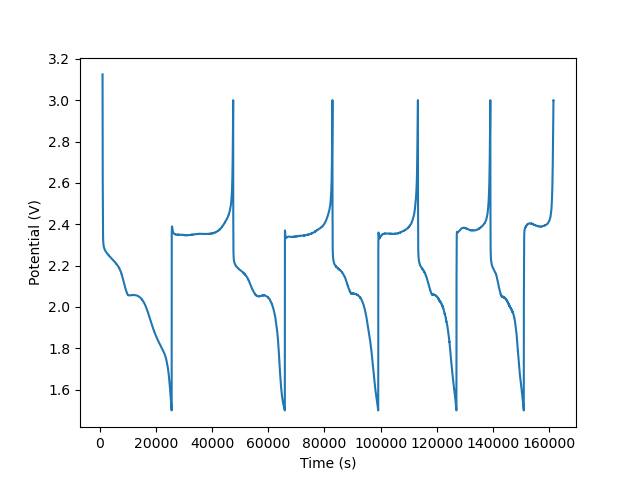

In [6]:
plt.figure()

elec_df_temp = pd.DataFrame(mpr.data)
# print(elec_df_temp)

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
absolute_times_for_electrochemical_state_change = []

# Add the very first values of the index and time 
cycle_change_index.append(elec_df.index[0])
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[0], 'time/s'])

for line in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[line] != elec_df['Ns'].iloc[line+1]:
        cycle_change_index.append(elec_df.index[line+1])
        absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

cycle_change_index.append(elec_df.index[line+1]) #Takes the index for the last file also  
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

print("Indices for cycle change", cycle_change_index)
print("\nAbsolute times for change in electrochemical state: ")
print(absolute_times_for_electrochemical_state_change)

# Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')

# Data Segregation

Total number of cycles: 5

Biologic data file line details:
Line numbers for each electrochemical change event : [961, 5886, 10270, 13952, 17345]
Corresponding times for each electrochemical change event:  ['960.00', '25573.21', '47482.70', '65881.16', '82833.19']
[6, 127, 234, 324, 408]


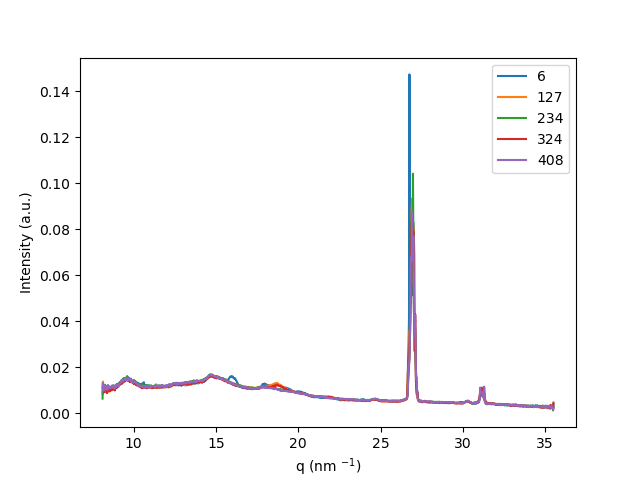

In [7]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))

change_cycle_line = []
discharge_start_time = []
saxs_file_numbers = []

starting_index_for_EC_data = 2*starting_cycle-2
ending_index_for_EC_data = 2*end_cycle

print('\nBiologic data file line details:')
print('Line numbers for each electrochemical change event :',
       [cycle_change_index[_] for _ in range(starting_index_for_EC_data, ending_index_for_EC_data+1)])
print('Corresponding times for each electrochemical change event: ', 
      [f"{absolute_times_for_electrochemical_state_change[i]:.2f}" for i in range(2*starting_cycle-2, 2*end_cycle+1)])

# creates a new data frame for the plot
elec_df_2 = elec_df.iloc[cycle_change_index[starting_index_for_EC_data] - cycle_change_index[0] : 
                         cycle_change_index[ending_index_for_EC_data] - cycle_change_index[0]]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

plt.style.use('default')
plt.figure()

# find the corresponding starting abd ending SAXS file
for entry in range(starting_index_for_EC_data, ending_index_for_EC_data+1):
    saxs_file_index, new_time_dict  = find_nearest_time(absolute_times_for_electrochemical_state_change[entry], time_stamp)
    saxs_file_numbers.append(saxs_file_index)
    X1_data = 10*file_dictionary[saxs_file_index].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y1_data = file_dictionary[saxs_file_index].iloc[:,1]
    plt.plot(X1_data, Y1_data, label= saxs_file_index)
""" # Printing the file details for manual verification of file numbers   
    print(f"Starting SAXS file no.: {saxs_file_index}")
    print('Time stamps:')
    print(time_stamp[saxs_file_index])"""
print(saxs_file_numbers)
starting_file = saxs_file_numbers[0]
last_file = saxs_file_numbers[-1]

plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()


# For Baseline correction (manually select the first long exposure file)

filtered position: 220, 633, value: 13.98411125091297, 24.995432407494583


C:\Users\b1104371\AppData\Local\Temp\ipykernel_37224\2779521468.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


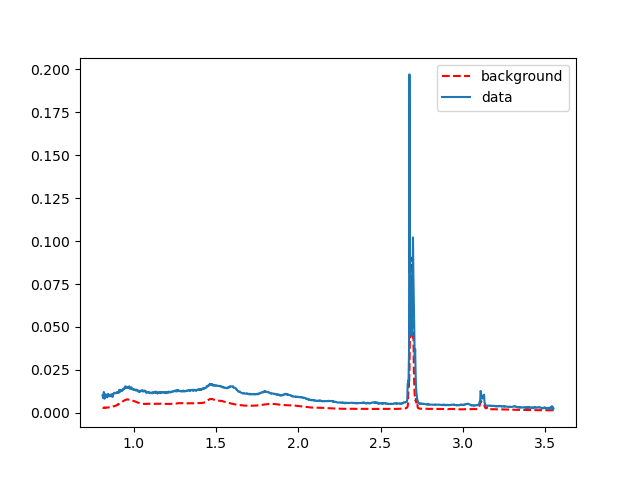

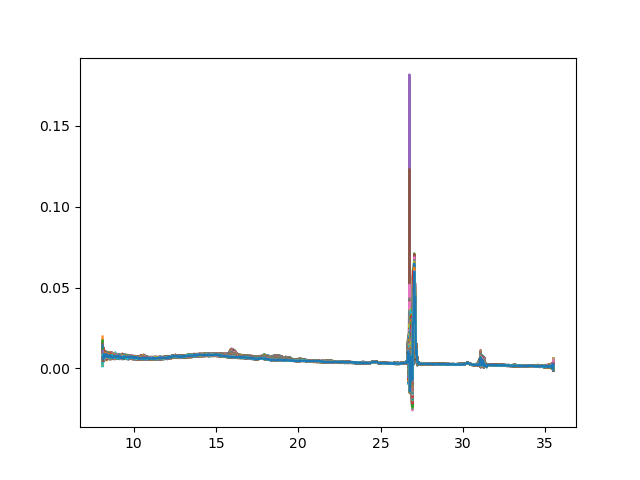

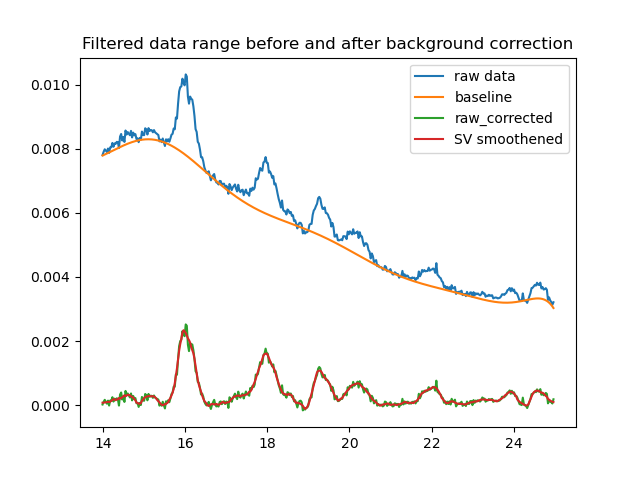

In [10]:
plt.figure()
#background_file = glob.glob('*_Al_WAXS.dat')
background_file = glob.glob('20240730_Empty_Cell_waxs.dat')

for file in background_file:
    a1,a2, background = read_data(file)

# print(background.iloc[:,0])
plt.plot(background.iloc[:,0], 1*background.iloc[:,1], 'r--', label = 'background')
plt.plot(file_dictionary[1].iloc[:,0],file_dictionary[1].iloc[:,1], label = 'data')
plt.legend()
plt.figure()

empty_cell_corrected_waxs_files = {}

for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - 1* background.iloc[:,1]
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    empty_cell_corrected_waxs_files[ikey] = df

#filter the range for the WAXS
filtered_X_range_min = np.max(np.where(X_data <= 14))
filtered_X_range_max = np.max(np.where(X_data <= 25))
# print(empty_cell_corrected_waxs_files)
print(f"filtered position: {filtered_X_range_min}, {filtered_X_range_max}, value: {X_data[filtered_X_range_min]}, {X_data[filtered_X_range_max]}")

                                  # Substract a polynomial over the empty cell corrected files #

# Create an average over the first four files for background generation
x_data = 0
y_data = 0
file_count = 0
for files in range(1,5):
    x_data += empty_cell_corrected_waxs_files[files].iloc[filtered_X_range_min:filtered_X_range_max,0]
    y_data += empty_cell_corrected_waxs_files[files].iloc[filtered_X_range_min:filtered_X_range_max,1]
    file_count += 1

# average over the summed data 
x_data = x_data/file_count
y_data = y_data/file_count

plt.figure()
plt.title("Filtered data range before and after background correction")
baseline_filter = Baseline(x_data = x_data)
baseline = baseline_filter.modpoly(y_data, poly_order= 10)[0]
# print(baseline)
modified_y = y_data-baseline
smoothed_Y = smooth_data(modified_y, window_length=11, polyorder=2)

plt.plot(x_data, y_data, label = 'raw data')
plt.plot(x_data, baseline, label = 'baseline')
plt.plot(x_data, modified_y, label = 'raw_corrected')
plt.plot(x_data, smoothed_Y, label = 'SV smoothened')
plt.legend()


# Create new file dictionary with corrected spectra
corrected_waxs_files = {}

for ikey in empty_cell_corrected_waxs_files:
    min_val = 0
    max_val = 0
    modified_Y = 0
    X1_values = empty_cell_corrected_waxs_files[ikey].iloc[filtered_X_range_min:filtered_X_range_max,0] 
    Y1_values = empty_cell_corrected_waxs_files[ikey].iloc[filtered_X_range_min:filtered_X_range_max,1]
    
    # define baselines for individual files and subtract from the data
    baseline_filter = Baseline(x_data = X1_values)
    baseline = baseline_filter.modpoly(Y1_values, poly_order= 10)[0]
    modified_Y = Y1_values - baseline

    # Smooth the data
    smoothed_Y = smooth_data(modified_Y, window_length=11, polyorder=2)

    # min_val = np.min(smoothed_Y)
    # max_val = np.max(smoothed_Y)
    normalized_Y = smoothed_Y #'(smoothed_Y - min_val)/(max_val - min_val)' # Normalized the data between [0,1]
    df = pd.DataFrame({'X_data': X1_values, 'Modified_Y': modified_Y}) # change the 'Modified_Y' as per the requirement, raw, smoothened or smoothened plus normalized 
    corrected_waxs_files[ikey] = df

cmap = cm.get_cmap('viridis')  
num_files = len(corrected_waxs_files)
colors = [cmap(i / num_files) for i in range(num_files)]  # Generate colors


# 3D waterfall plot

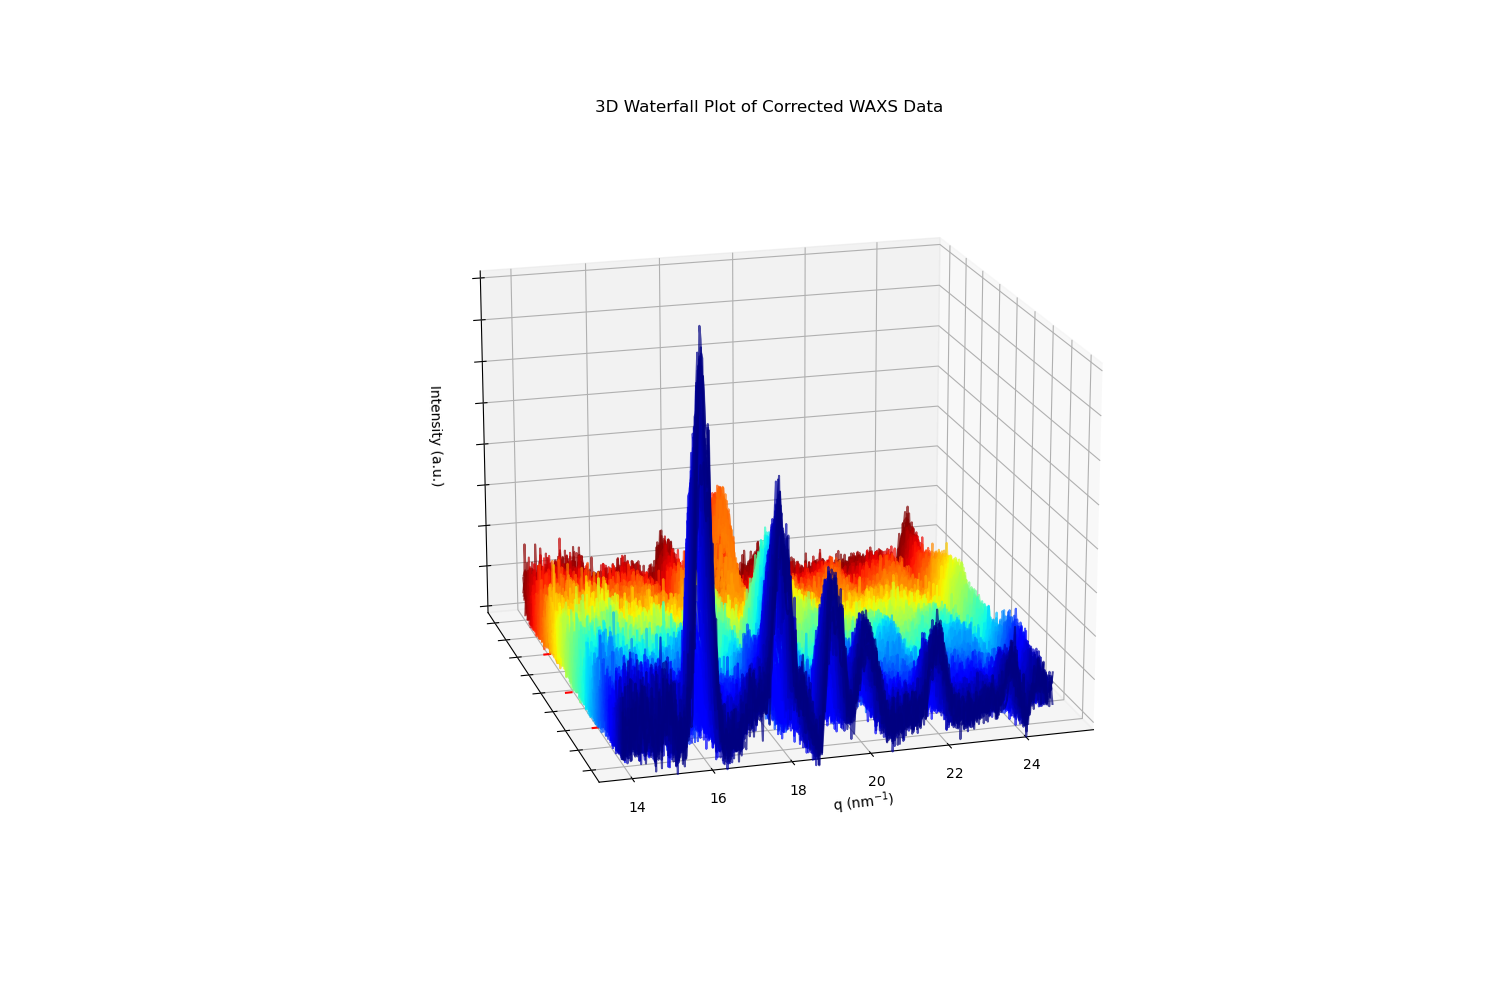

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Initialize the figure
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
plt.title("3D Waterfall Plot of Corrected WAXS Data")

# Base offset for the waterfall plot
base_offset = 0.0
offset_increment = 0.00001  # value to increase/decrease the spacing between curves

# Set the transparency level
transparency = 0.7  

# List of keys and reverse it
keys = list(range(starting_file, last_file + 1))
keys.reverse()  # Reverse the order

# Adjust the saxs_file_numbers list to exclude the first and last entries
adjusted_saxs_file_numbers = saxs_file_numbers[1:-1]  # Exclude first and last entries

for ikey in keys:
    # Extract the X and Y values
    X1_values = corrected_waxs_files[ikey].iloc[:, 0] 
    modified_Y = corrected_waxs_files[ikey].iloc[:, 1]  
    
    # Apply vertical offset for the Z axis (used for time or series offset)
    offset = base_offset + (ikey - starting_file) * offset_increment
    Z = np.full_like(X1_values, offset)  # Constant Z value for this curve
    
    # Plot the curve in 3D with transparency
    ax.plot(X1_values, Z, modified_Y, color=cm.jet((ikey - starting_file) / (last_file - starting_file)), alpha=transparency)

    # Mark the z-axis if ikey is in the adjusted saxs_file_numbers
    if ikey in adjusted_saxs_file_numbers:
        ax.plot([X1_values.min(), X1_values.max()], [offset, offset], [modified_Y.min(), modified_Y.min()], 
                color='red', linestyle='--', linewidth=1.5, label=f"Marker for ikey {ikey}")

# Set axis labels
ax.set_xlabel('q (nm$^{-1}$)')
ax.set_ylabel('') 
ax.set_zlabel('Intensity (a.u.)')
ax.zaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

# Set limits and view angle
# ax.set_xlim(14, 25)
ax.set_zlim(0, 0.004)
ax.view_init(elev=18, azim=-106)  # elevation and azimuth to adjust the 3D view

# Show the plot with the marker
plt.show()


In [36]:
# Open a text file in write mode
with open('waxs_data.txt', 'w') as file:
    # Write header
    file.write("X1_value\t" + "\t".join([f"modified_Y_{ikey}" for ikey in corrected_waxs_files]) + "\n")
    
    # Extract the X1 values from the first file
    first_X1_values = corrected_waxs_files[list(corrected_waxs_files.keys())[0]].iloc[:, 0]
    
    # Loop over the X1 values (rows)
    for i in range(len(first_X1_values)):
        # Get the first X1_value from the first file
        x1_value = first_X1_values.iloc[i]
        
        # Collect corresponding modified_Y values from all files
        y_values = [corrected_waxs_files[ikey].iloc[i, 1] for ikey in corrected_waxs_files]
        
        # Write X1_value followed by all corresponding Y values
        file.write(f"{x1_value}\t" + "\t".join([str(y) for y in y_values]) + "\n")

print("Data written to waxs_data.txt")


Data written to waxs_data.txt


# Creating the Polynomial background (With a average over the first three files)

'plt.xlim(15,22)\nplt.ylim(-0.001,0.008)'

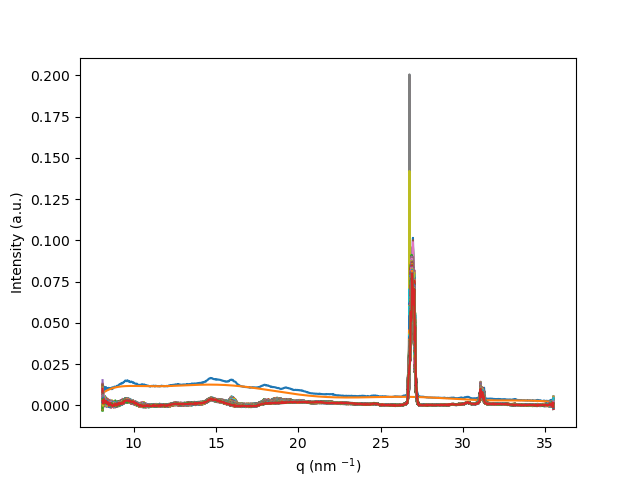

In [14]:
X_data = []
Y_data = []

# Create a average over the first three data files 
plt.figure()
for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary[files].iloc[:,1]
        # print(X_data)
    else:
        X_data += 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data += file_dictionary[files].iloc[:,1]

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 10)[0]
# print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

# Create new file dictionary with corrected spectra
corrected_waxs_files = {}
for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
"""plt.xlim(15,22)
plt.ylim(-0.001,0.008)"""

# Check the plot for determination of two-theta and no of peaks for fitting 

[0, 0, 0, 0, 0, 0, -0.00022952632308667793]
Peak 1:
 Amplitude = 0.0034 +/- 0.0004
 Center = 16.00
 Width = 0.2322 +/- 0.0517
Peak 2:
 Amplitude = 0.0011 +/- 0.0517
 Center = 17.90
 Width = 0.0916 +/- 0.0627
Peak 3:
 Amplitude = 0.0030 +/- 0.0005
 Center = 18.74
 Width = 1.0000 +/- 0.2409
[ 3.41562869e-03  2.32248256e-01  1.10696988e-03  9.15838388e-02
  3.03135402e-03  9.99999999e-01 -1.97159705e-04]


Text(0, 0.5, 'Intensity (a.u.)')

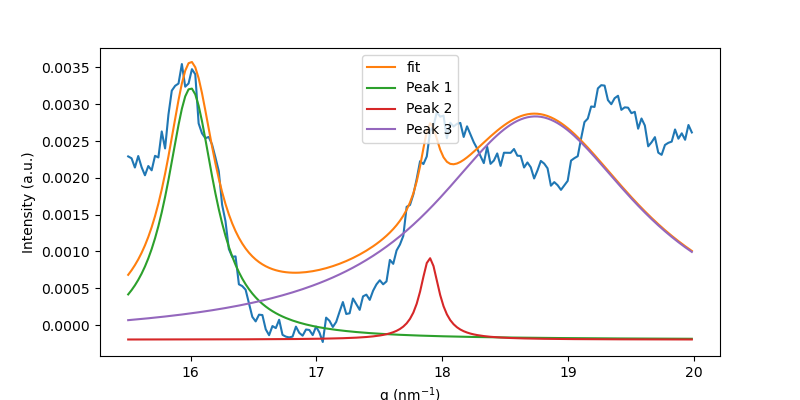

In [31]:
# Filter data between ranges

min_x = 15.5
max_x = 20

X_positions = corrected_waxs_files[starting_file].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

# Create new list with the filtered data 

x_filtered = []
y_filtered = [] 

for entry in range(start_row, end_row+1):
    x_temp = corrected_waxs_files[1].iloc[entry,0]
    y_temp = corrected_waxs_files[1].iloc[entry,1]
    x_filtered.append(x_temp)
    y_filtered.append(y_temp)

x_filtered = np.array(x_filtered)
y_filtered = np.array(y_filtered)

# mean_positions = [18.5, 19.1, 19.5, 19.9, 20.8]
# mean_positions = [18.6, 19.13, 19.9, 20.8]
mean_positions = [16, 17.9, 18.74]
# mean_positions = [19,19.8]

initial_guess = [0.001, 0.1] * len(mean_positions) + [np.min(y_filtered)]

lower_bounds = [0, 0] * (len(mean_positions)) + [np.min(y_filtered)]
print(lower_bounds)  # Lower and upper bounds for amplitude and width
upper_bounds = [np.inf, 1.0] * (len(mean_positions)) +[0.1]
bounds = (lower_bounds, upper_bounds)

popt_lorentz, pcov_lorentz = curve_fit(multi_lorentzian, xdata= x_filtered, ydata= y_filtered, 
                                       p0 = initial_guess, bounds= bounds, max_nfev=100000)

perr_lorentzian = np.sqrt(np.diag(pcov_lorentz)) # Calculating the errors from the functions


for i in range(len(mean_positions)):
    print(f"Peak {i+1}:")
    print(f" Amplitude = {popt_lorentz[2*i]:.4f} +/- {perr_lorentzian[i]:.4f}")
    print(f" Center = {mean_positions[i]:.2f}")
    print(f" Width = {popt_lorentz[2*i +1]:.4f} +/- {perr_lorentzian[2*i +1]:.4f}")

plt.figure(figsize= (8,4))      
print(popt_lorentz)
plt.plot(x_filtered, y_filtered)
plt.plot(x_filtered, multi_lorentzian(x_filtered, *popt_lorentz), label = 'fit')

#for i in range(0, len(popt_lorentz), 3):
#    plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[i], popt_lorentz[i+1], popt_lorentz[i+2]), label=f'Peak {i//3 + 1}')

for j in range(len(mean_positions)):
    plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[2*j], mean_positions[j], 
                                    popt_lorentz[2*j+1]) + popt_lorentz[-1], label=f'Peak {j + 1}')
    plt.legend()

plt.xlabel("q (nm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")


In [25]:
# Filter data between ranges

X_positions = corrected_waxs_files[starting_file].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

df_curves = pd.DataFrame() # Dataframe to save the fitted peak area and widths 


# Define bounds for amplitude and width Required to keep amplitudes within positive values

# Create new list with the filtered data 
for file_number in range(starting_file, last_file+1):
    #print(file_number)
    x_filtered = []
    y_filtered = [] 
    lower_bounds = []
    upper_bounds = []

    for entry in range(start_row, end_row+1):
        x_temp = corrected_waxs_files[file_number].iloc[entry,0]
        y_temp = corrected_waxs_files[file_number].iloc[entry,1]
        x_filtered.append(x_temp)
        y_filtered.append(y_temp)

    x_filtered = np.array(x_filtered)
    y_filtered = np.array(y_filtered)
    
    # Define bounds for amplitude and width Required to keep amplitudes within positive values

    initial_guess = [0.0001, 0.1] * len(mean_positions) + [np.min(y_filtered)] # List for initial guesses for peak amplitude, width and baseline
    lower_bounds = [0, 0] * (len(mean_positions)) + [np.min(y_filtered)] # Lower and upper bounds for amplitude and width
    upper_bounds = [np.inf, 1.5] * (len(mean_positions)) + [1.0]
    bounds = (lower_bounds, upper_bounds)

    popt_lorentz, pcov_lorentz = curve_fit(multi_lorentzian, xdata= x_filtered, ydata= y_filtered, p0 = initial_guess, bounds= bounds, max_nfev=10000)

    perr_lorentzian = np.sqrt(np.diag(pcov_lorentz)) # Calculating the errors from the functions
    temp_dict = {}

    for i in range(len(mean_positions)):
        curve_metrics = [] 
        amplitude = popt_lorentz[2*i] - popt_lorentz[-1]
        w0 = popt_lorentz[2*i +1]
        area = np.pi*amplitude*w0
        width = 2*w0
        curve_metrics.append([area,width])
        temp_dict[i+1] = curve_metrics
        temp_df_curve = pd.DataFrame(temp_dict, index= [file_number])

    df_curves = pd.concat([df_curves, temp_df_curve])
print(len(df_curves))
#print(df_curves.head())

403


[0.003280765836630171, 0.004006593752742008, 0.0038665699385117764, 0.0037654497378373647, 0.003916263278327861, 0.004073697213251574, 0.0038116770364772755, 0.0038700779970044217, 0.003708686832969621, 0.00369427762618535, 0.003902336085513496, 0.0034692049884912993, 0.0037035336791330408, 0.003540929622437635, 0.003797542791370391, 0.0037914750374913255, 0.003558275761339036, 0.00355555889968802, 0.0035525732664487904, 0.0031780372557799657, 0.0034145056531219753, 0.0032017726413263803, 0.0033575518036963944, 0.0030651991063001074, 0.0031603959376799435, 0.0030681962070517213, 0.003208489290331869, 0.0031058116449993907, 0.0032733892212921142, 0.0030532586111650883, 0.0031339216889880368, 0.0033883054849337246, 0.0029332098865994787, 0.003095650241351447, 0.0026551168810240635, 0.0030494753315818313, 0.0029840410208153644, 0.002493001937223887, 0.0025571571612800093, 0.0025174895111793323, 0.0026264160118400957, 0.002474542153354624, 0.002426838117826773, 0.0019767544752780034, 0.001

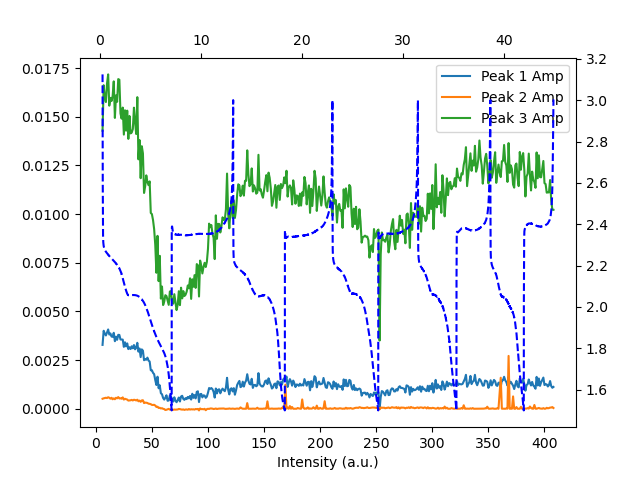

In [26]:
x1, y1, y2, y3, y4, y5 = [[] for _ in range(6)]

for data in range(df_curves.index[0],df_curves.index[-1]+1):
    x1.append(data)
    y1.append(df_curves.loc[data,1][0])
    y2.append(df_curves.loc[data,2][0])
    y3.append(df_curves.loc[data,3][0])
    #y4.append(df_curves.loc[data,4][0])
    #y5.append(df_curves.loc[data,5][0])
print(y1)
"""
plt.figure()
plt.title("Peak areas vs cycle number")
plt.plot(x1,y1, label = 'Peak 1 Amp' )
plt.plot(x1,y2, label = 'Peak 2 Amp')
plt.plot(x1,y3, label = 'Peak 3 Amp')
# plt.plot(x1,y4, label = 'Peak 4 Amp')
# plt.plot(x1,y5, label = 'Peak 5 Amp')
plt.legend()
"""

fig2, ax1 = plt.subplots()
ax1.plot(x1,y1, label = 'Peak 1 Amp' )
ax1.plot(x1,y2, label = 'Peak 2 Amp')
ax1.plot(x1,y3, label = 'Peak 3 Amp')
ax1.set_xlabel('Intensity (a.u.)')
# ax1.plot(x1,y4, label = 'Peak 4 Amp')
# ax1.plot(x1,y5, label = 'Peak 5 Amp')
ax2 = fig2.add_axes(ax1.get_position(), frameon=False)
ax2.plot(Elec_Xdata/3600 ,Elec_Ydata, 'b--')
ax2.xaxis.set_ticks_position('top')
ax2.yaxis.set_ticks_position('right')
ax1.legend()


ValueError: x and y must have same first dimension, but have shapes (1,) and (0,)

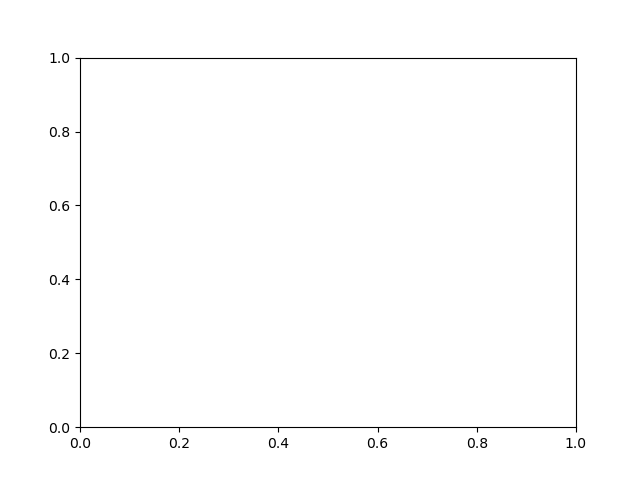

In [22]:
sum_sulfur = [(x + y)/2 for x,y in zip(y1, y5)]
sum_li2S = [(x + y + z)/3 for x,y,z in zip(y2,y3,y4)]

fig, ax1 = plt.subplots()

ax1.plot(x1, sum_sulfur, label = 'sulfur')
ax1.plot(x1, sum_li2S, label = 'Li2S')
ax2 = fig.add_axes(ax1.get_position(), frameon=False)
ax2.plot(Elec_Xdata,Elec_Ydata, 'g--')
ax2.xaxis.set_ticks_position('top')
ax2.yaxis.set_ticks_position('right')

ax1.legend()

In [ ]:
ap = [1,2,3]
ao = [3,4,5]
ap += ao
print(ap)

[1, 2, 3, 3, 4, 5]
